In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_iris, make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model.fit(X_train, y_train)

print(f"Train Accuracy: {accuracy_score(y_train, model.predict(X_train))*100:.1f}%")
print(f"Test  Accuracy: {accuracy_score(y_test,  model.predict(X_test))*100:.1f}%")
print()
print(classification_report(y_test, model.predict(X_test), target_names=iris.target_names))

Train Accuracy: 97.5%
Test  Accuracy: 100.0%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



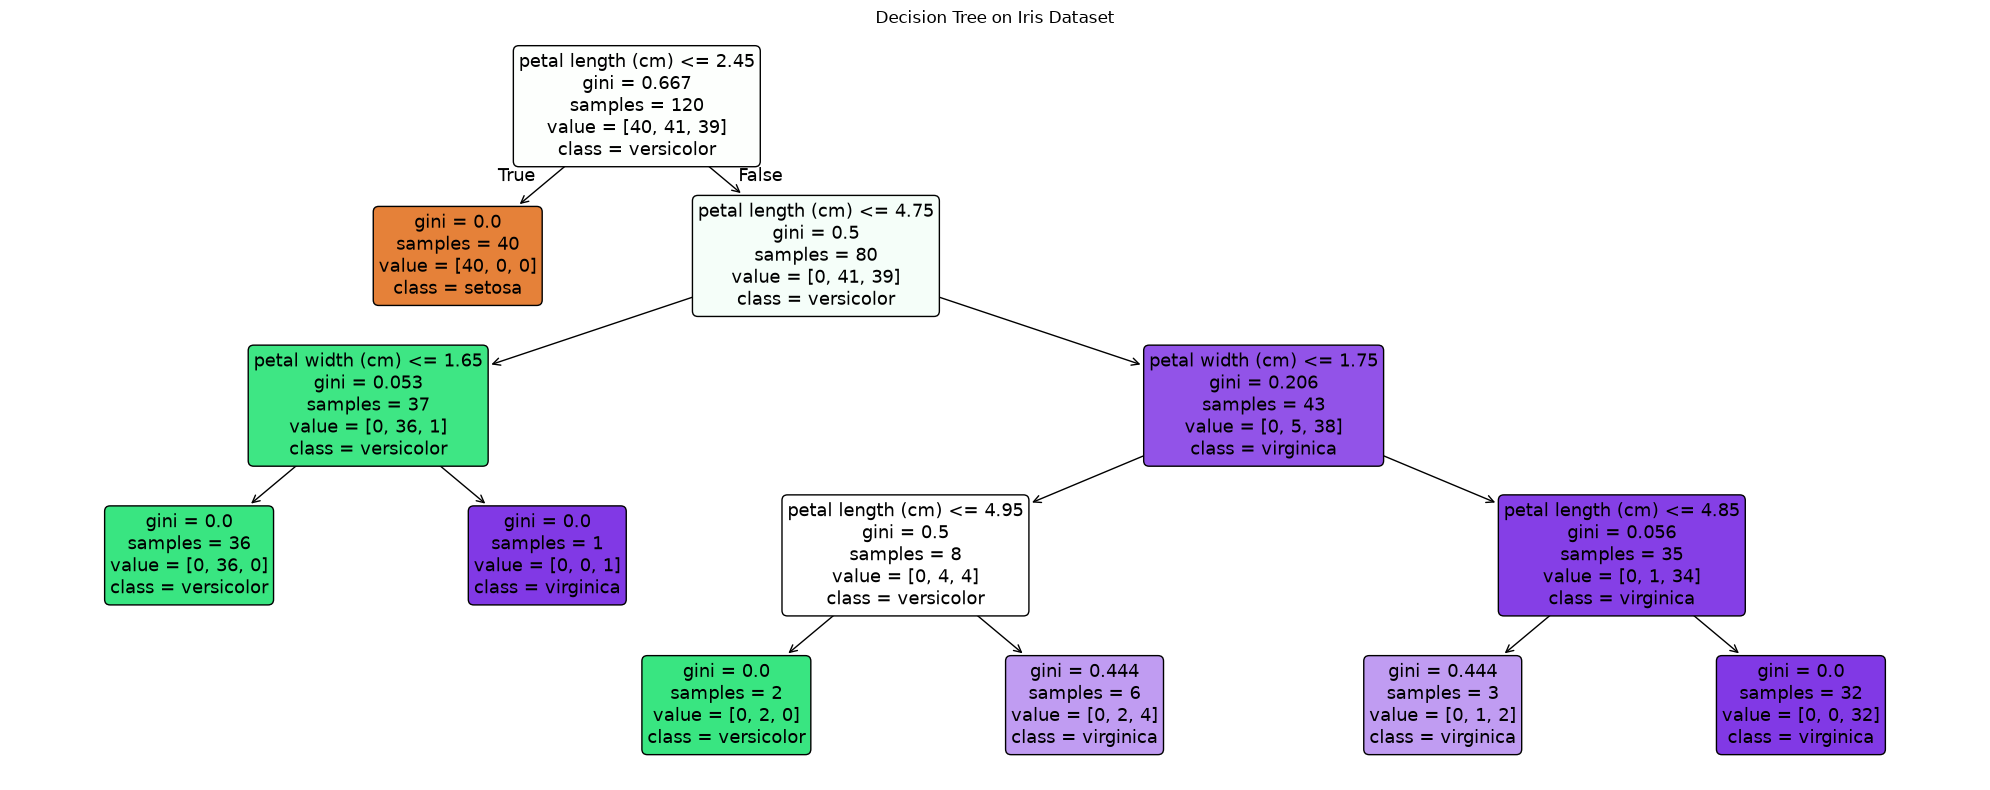

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



In [3]:
# Cell 3 — Version 2: visualise the actual tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, ax=ax)
plt.title('Decision Tree on Iris Dataset')
plt.tight_layout(); plt.show()

# also print as text
print(export_text(model, feature_names=iris.feature_names))

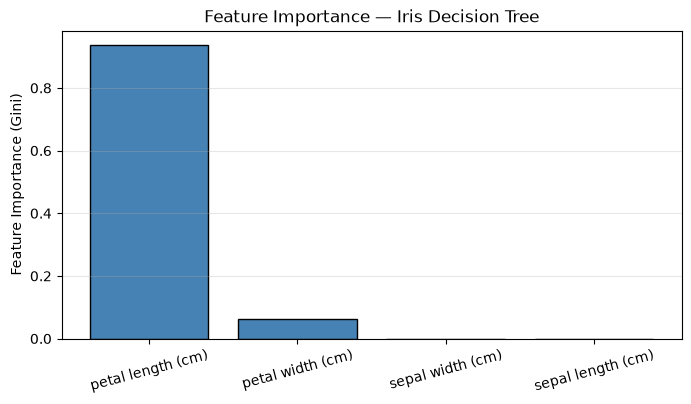

petal length (cm)             : 0.9363
petal width (cm)              : 0.0637
sepal width (cm)              : 0.0000
sepal length (cm)             : 0.0000


In [4]:
# Cell 4 — Version 3: feature importance bar chart
importances = model.feature_importances_
features    = iris.feature_names
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(features)), importances[sorted_idx], color='steelblue', edgecolor='black')
plt.xticks(range(len(features)), [features[i] for i in sorted_idx], rotation=15)
plt.ylabel('Feature Importance (Gini)')
plt.title('Feature Importance — Iris Decision Tree')
plt.grid(True, alpha=0.3, axis='y'); plt.show()

for i in sorted_idx:
    print(f"{features[i]:30s}: {importances[i]:.4f}")

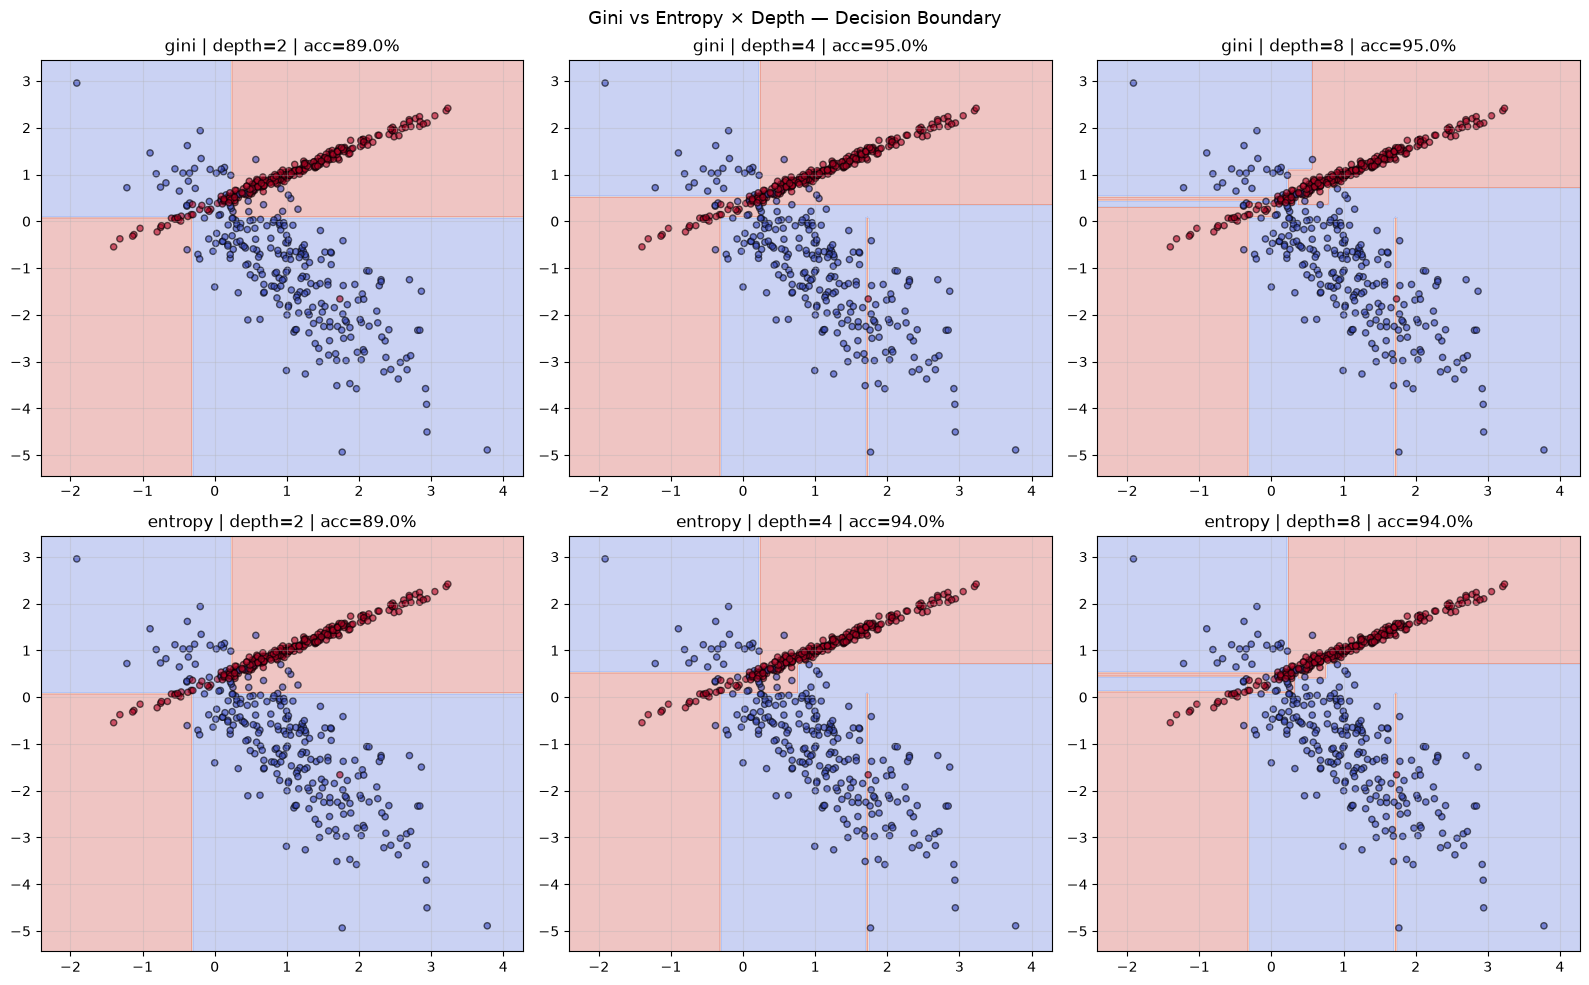

In [5]:
# Cell 5 — Version 4: gini vs entropy + max_depth comparison
from sklearn.datasets import make_classification

np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, criterion in enumerate(['gini', 'entropy']):
    for col, depth in enumerate([2, 4, 8]):
        model = DecisionTreeClassifier(criterion=criterion,
                                       max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))

        x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
        y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        ax = axes[row][col]
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm',
                   edgecolors='k', s=20, alpha=0.6)
        ax.set_title(f'{criterion} | depth={depth} | acc={acc*100:.1f}%')
        ax.grid(True, alpha=0.3)

plt.suptitle('Gini vs Entropy × Depth — Decision Boundary', fontsize=13)
plt.tight_layout(); plt.show()